# Abgabe 4 – Kapitel 8: Dimensionsreduktion

Programmieraufgaben aus *Hands-On Machine Learning* (Aurélien Géron), Kapitel 8.

- Aufgabe 9: Random Forest auf MNIST, PCA (95 %) und SGDClassifier.
- Aufgabe 10: t-SNE-Visualisierung der ersten 5.000 MNIST-Bilder, Vergleich mit PCA, LLE und MDS.

## Aufgabe 9: Random Forest, PCA und SGD auf MNIST

MNIST laden, erste 60.000 zum Trainieren, restliche 10.000 zum Testen.

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
print('Training:', X_train.shape, '| Test:', X_test.shape)

Training: (60000, 784) | Test: (10000, 784)


### Random Forest auf dem vollständigen Datensatz

Training mit Laufzeitmessung.

In [2]:
import time
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)

t0 = time.time()
rnd_clf.fit(X_train, y_train)
train_time_full = time.time() - t0
print('Trainingszeit (volle 784 Dimensionen): {:.1f} s'.format(train_time_full))

Trainingszeit (volle 784 Dimensionen): 127.9 s


In [3]:
from sklearn.metrics import accuracy_score

acc_full = accuracy_score(y_test, rnd_clf.predict(X_test))
print('Testgenauigkeit (volle 784 Dimensionen): {:.4f}'.format(acc_full))

Testgenauigkeit (volle 784 Dimensionen): 0.9705


### Dimensionsreduktion mit PCA (95 %)

Reduktion auf 95 % erklärte Streuung.

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)
print('Dimensionen:', X_train.shape[1], '->', pca.n_components_)

Dimensionen: 784 -> 154


### Random Forest auf dem reduzierten Datensatz

Gleiches Modell, gleiche Messung.

In [5]:
rnd_clf_reduced = RandomForestClassifier(n_estimators=100, random_state=42)

t0 = time.time()
rnd_clf_reduced.fit(X_train_reduced, y_train)
train_time_reduced = time.time() - t0

print('Trainingszeit  (volle 784 Dim.):     {:.1f} s'.format(train_time_full))
print('Trainingszeit  ({:>3} PCA-Dim.):       {:.1f} s'.format(
    pca.n_components_, train_time_reduced))

Trainingszeit  (volle 784 Dim.):     127.9 s
Trainingszeit  (154 PCA-Dim.):       412.2 s


In [6]:
acc_reduced = accuracy_score(y_test, rnd_clf_reduced.predict(X_test_reduced))

print('Testgenauigkeit (volle 784 Dim.):    {:.4f}'.format(acc_full))
print('Testgenauigkeit ({:>3} PCA-Dim.):      {:.4f}'.format(
    pca.n_components_, acc_reduced))

Testgenauigkeit (volle 784 Dim.):    0.9705
Testgenauigkeit (154 PCA-Dim.):      0.9488


Beobachtung: Das Training mit PCA ist langsamer statt schneller, und die Genauigkeit sinkt
von rund 97 % auf etwa 95 %.

### Dasselbe mit einem SGDClassifier

Volle Daten gegen PCA-Daten.

In [7]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)

t0 = time.time()
sgd_clf.fit(X_train, y_train)
sgd_time_full = time.time() - t0
sgd_acc_full = accuracy_score(y_test, sgd_clf.predict(X_test))
print('SGD – volle 784 Dim.:  Trainingszeit {:6.1f} s,  Testgenauigkeit {:.4f}'.format(
    sgd_time_full, sgd_acc_full))

SGD – volle 784 Dim.:  Trainingszeit  436.3 s,  Testgenauigkeit 0.8674


In [8]:
sgd_clf_reduced = SGDClassifier(random_state=42)

t0 = time.time()
sgd_clf_reduced.fit(X_train_reduced, y_train)
sgd_time_reduced = time.time() - t0
sgd_acc_reduced = accuracy_score(y_test, sgd_clf_reduced.predict(X_test_reduced))
print('SGD – {:>3} PCA-Dim.:    Trainingszeit {:6.1f} s,  Testgenauigkeit {:.4f}'.format(
    pca.n_components_, sgd_time_reduced, sgd_acc_reduced))

SGD – 154 PCA-Dim.:    Trainingszeit   95.0 s,  Testgenauigkeit 0.8931


Beobachtung: Mit PCA trainiert der SGDClassifier rund fünfmal schneller, und die Genauigkeit
steigt leicht.

## Aufgabe 10: Visualisierung mit t-SNE und Vergleich

Erste 5.000 MNIST-Bilder mit t-SNE auf zwei Dimensionen.

In [9]:
import numpy as np

m = 5000
X_sample = X_train[:m]
y_sample = y_train[:m].astype(np.uint8)

In [10]:
from sklearn.manifold import TSNE

t0 = time.time()
tsne = TSNE(n_components=2, init='random', learning_rate='auto', random_state=42)
X_tsne = tsne.fit_transform(X_sample)
print('t-SNE fertig in {:.1f} s'.format(time.time() - t0))

t-SNE fertig in 105.7 s


Streudiagramm mit zehn Farben (Hilfsfunktion, mehrfach genutzt).

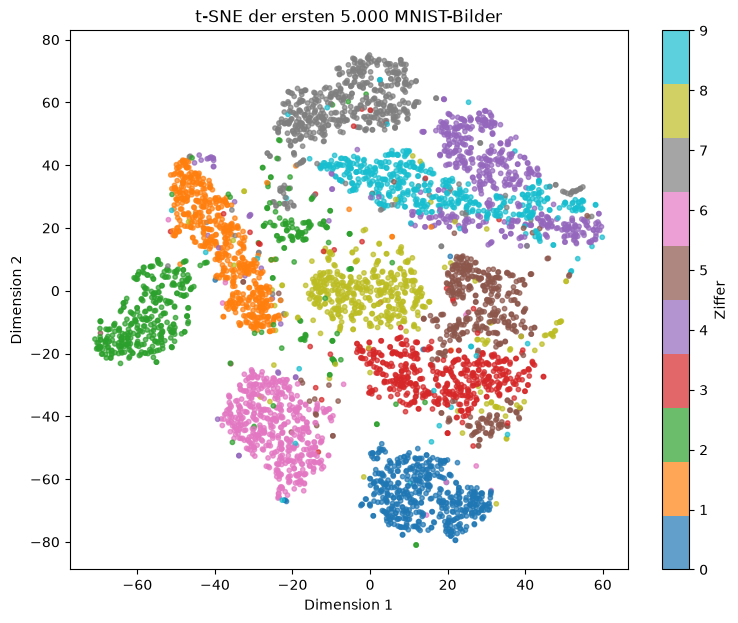

In [11]:
import matplotlib.pyplot as plt

def plot_2d(X_2d, y, titel):
    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=10, alpha=0.7)
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label('Ziffer')
    plt.title(titel)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.show()

plot_2d(X_tsne, y_sample, 't-SNE der ersten 5.000 MNIST-Bilder')

Beobachtung: Die zehn Ziffern bilden zehn gut getrennte Cluster; nur ähnliche Ziffern wie
4/9 und 3/5 überlappen am Rand.

Jede Position als Ziffer statt als Punkt.

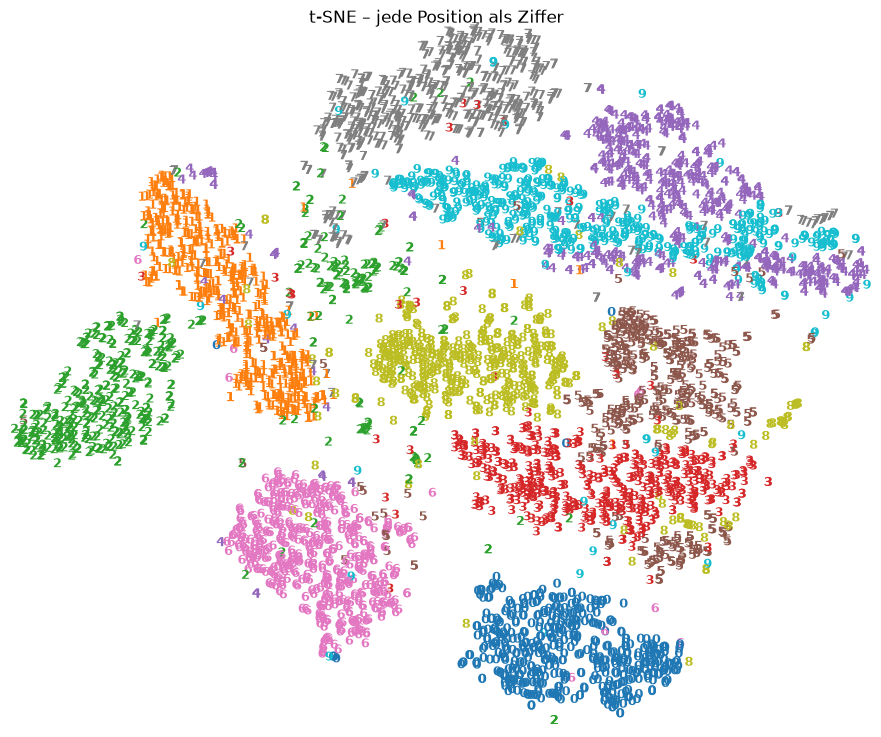

In [12]:
def plot_digits_text(X_2d, y, titel, figsize=(11, 9)):
    X_min, X_max = X_2d.min(axis=0), X_2d.max(axis=0)
    X_norm = (X_2d - X_min) / (X_max - X_min)
    plt.figure(figsize=figsize)
    cmap = plt.cm.tab10
    for i in range(len(X_norm)):
        plt.text(X_norm[i, 0], X_norm[i, 1], str(y[i]),
                 color=cmap(int(y[i])), fontdict={'weight': 'bold', 'size': 9})
    plt.title(titel)
    plt.axis('off')
    plt.show()

plot_digits_text(X_tsne, y_sample, 't-SNE – jede Position als Ziffer')

Verkleinerte Originalbilder an ihrer 2D-Position, überlappungsfrei.

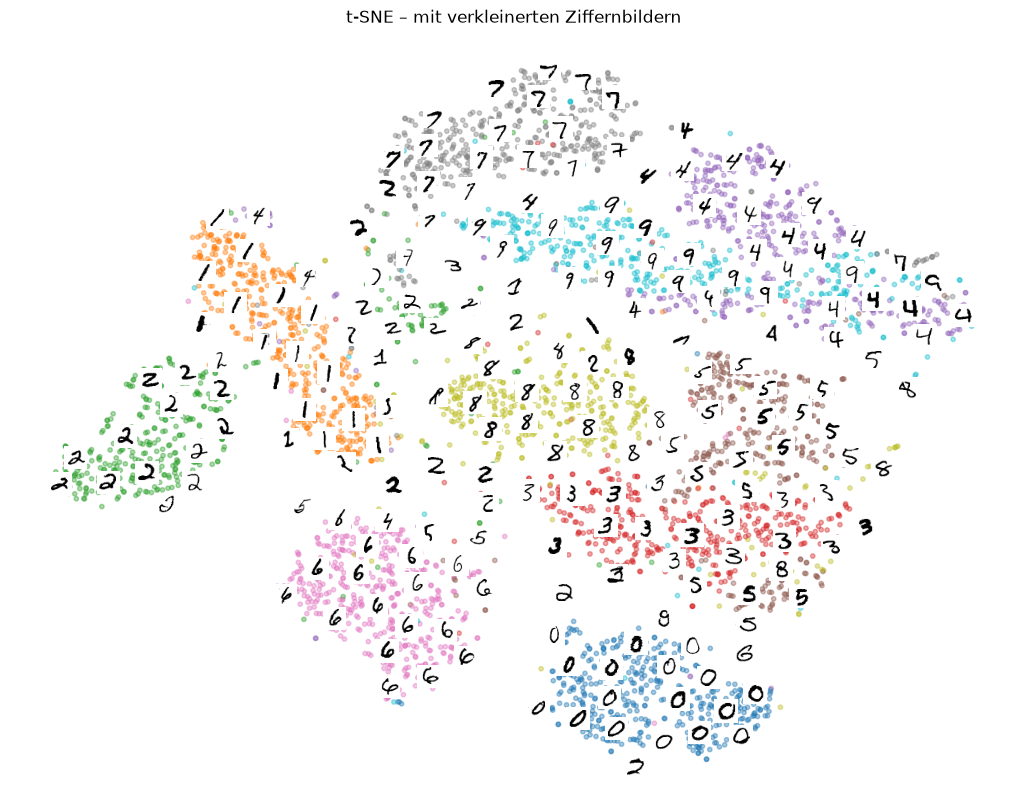

In [13]:
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

def plot_digits_images(X_2d, y, images, min_distance=0.04, figsize=(13, 10)):
    X_min, X_max = X_2d.min(axis=0), X_2d.max(axis=0)
    X_norm = (X_2d - X_min) / (X_max - X_min)

    plt.figure(figsize=figsize)
    plt.scatter(X_norm[:, 0], X_norm[:, 1], c=y, cmap='tab10', s=10, alpha=0.4)
    plt.axis('off')

    ax = plt.gca()
    gezeichnet = np.array([[10.0, 10.0]])
    for i in range(len(X_norm)):
        if np.linalg.norm(X_norm[i] - gezeichnet, axis=1).min() < min_distance:
            continue
        gezeichnet = np.vstack([gezeichnet, X_norm[i]])
        bild = OffsetImage(images[i].reshape(28, 28), cmap='binary', zoom=0.6)
        ax.add_artist(AnnotationBbox(bild, X_norm[i], frameon=False))
    plt.title('t-SNE – mit verkleinerten Ziffernbildern')
    plt.show()

plot_digits_images(X_tsne, y_sample, X_sample)

### Vergleich mit PCA, LLE und MDS

PCA, LLE und t-SNE auf allen 5.000 Bildern, MDS (sehr langsam) auf 2.000.

In [14]:
from sklearn.manifold import LocallyLinearEmbedding, MDS

m_mds = 2000
X_mds_sample = X_train[:m_mds]
y_mds_sample = y_train[:m_mds].astype(np.uint8)

ergebnisse = []   # (Name, 2D-Einbettung, Farbwerte)

t0 = time.time()
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_sample)
print('PCA   (5.000 Bilder) fertig ({:6.1f} s)'.format(time.time() - t0))
ergebnisse.append(('PCA', X_pca, y_sample))

t0 = time.time()
X_lle = LocallyLinearEmbedding(n_components=2, random_state=42).fit_transform(X_sample)
print('LLE   (5.000 Bilder) fertig ({:6.1f} s)'.format(time.time() - t0))
ergebnisse.append(('LLE', X_lle, y_sample))

t0 = time.time()
X_mds = MDS(n_components=2, n_init=1, normalized_stress=False,
            random_state=42).fit_transform(X_mds_sample)
print('MDS   (2.000 Bilder) fertig ({:6.1f} s)'.format(time.time() - t0))
ergebnisse.append(('MDS (2.000 Bilder)', X_mds, y_mds_sample))

ergebnisse.append(('t-SNE', X_tsne, y_sample))

PCA   (5.000 Bilder) fertig (   3.2 s)
LLE   (5.000 Bilder) fertig (   9.4 s)


c:\Users\Patri\anaconda3\envs\male\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


MDS   (2.000 Bilder) fertig ( 122.4 s)


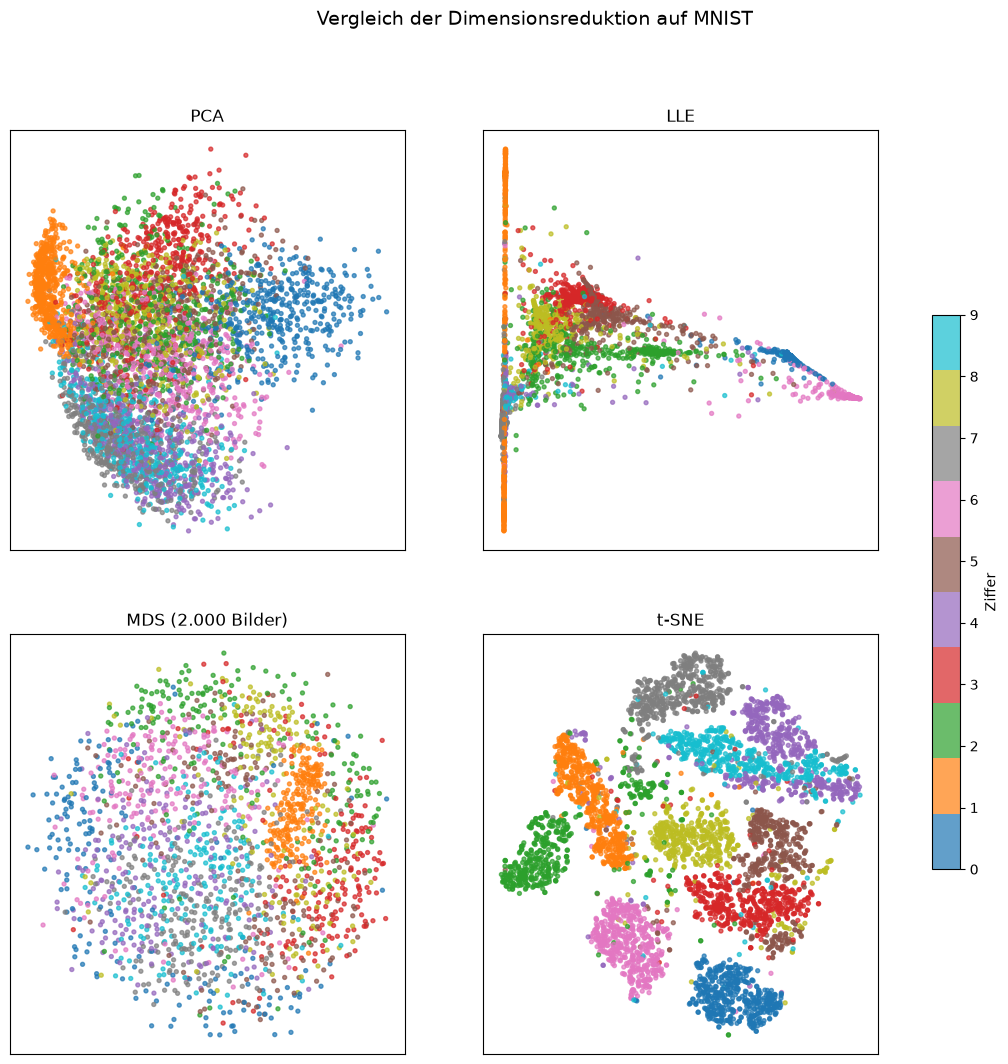

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (name, X_2d, farben) in zip(axes.ravel(), ergebnisse):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=farben, cmap='tab10', s=8, alpha=0.7)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(sc, ax=list(axes.ravel()), ticks=range(10), label='Ziffer', shrink=0.6)
plt.suptitle('Vergleich der Dimensionsreduktion auf MNIST', fontsize=14)
plt.show()

Beobachtung: t-SNE trennt die Ziffern am klarsten. PCA ist am schnellsten, trennt aber kaum.
LLE trennt schlecht. MDS bleibt diffus und ist am langsamsten.